# Episode 2 — Parameter Efficient Fine-Tuning (PEFT) with LoRA

### *Building LLM & Agentic AI Applications* — Short Course

Welcome back! In Episode 1 you learned the fundamentals of LLMs, prompt engineering, in-context learning, and the LLM project lifecycle.

Today we get our hands dirty with our **first hands-on LLM project**: fine-tuning a small open-source LLM using **LoRA (Low-Rank Adaptation)**, a Parameter-Efficient Fine-Tuning (PEFT) technique.


## 1. Introduction

### What we are building

We will take a small, general-purpose instruction-tuned LLM and **specialize it** for a concrete task: **banking customer support intent classification**.

Given a customer message like:

> "I still haven't received the money someone sent me"

the model must output the correct **intent label**, e.g. `transfer_not_received_by_recipient`.

We will:

1. Load a small open-source LLM.
2. Load a small, focused dataset from Hugging Face.
3. Evaluate the **base model** on this task (spoiler: it will struggle).
4. Fine-tune the model using **LoRA**.
5. Evaluate the **fine-tuned model** and compare it to the base model.
6. Discuss when fine-tuning is the right tool, versus prompt engineering or RAG.

### Learning objectives

By the end of this notebook you will be able to:

- Load an open-source LLM and a Hugging Face dataset.
- Evaluate a base model on a task and identify its weaknesses.
- Explain what LoRA is and how PEFT works, intuitively.
- Fine-tune an LLM with LoRA using `trl`'s `SFTTrainer`.
- Evaluate a fine-tuned model with standard classification metrics.
- Decide when to reach for fine-tuning instead of prompting or RAG.

### Expected outcome

The base model will often produce inconsistent, made-up, or wrongly-formatted intents.
After a few minutes of LoRA fine-tuning, the model will reliably output **valid, correctly formatted, and mostly correct** intent labels — measured with accuracy, precision, recall and F1.

### Pipeline overview

```mermaid
flowchart LR
    A[Load Dataset] --> B[Load Base Model]
    B --> C[Baseline Evaluation]
    C --> D[Configure LoRA]
    D --> E[Fine-Tune]
    E --> F[Evaluate Fine-Tuned Model]
    F --> G[Compare & Discuss]
```


## 2. Install Libraries

We only need a handful of libraries, all standard in the Hugging Face ecosystem:

| Library | Purpose |
|---|---|
| `transformers` | Load the model and tokenizer |
| `datasets` | Load and manipulate the Hugging Face dataset |
| `peft` | LoRA implementation |
| `trl` | `SFTTrainer` — simplifies supervised fine-tuning |
| `evaluate` | Standard evaluation metrics |
| `accelerate` | Efficient device handling for training |
| `torch` | Deep learning backend |
| `pandas`, `matplotlib`, `scikit-learn` | Data wrangling and plotting |

Run the cell below once at the start of the session.


In [4]:
# Check the clean Colab environment
import sys

print("Python:", sys.version)

!pip uninstall -y torch torchvision torchaudio

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128


In [5]:
!pip install -q \
    torch==2.11.0 \
    torchvision==0.26.0 \
    torchaudio==2.11.0 \
    torchao>=0.16.0 \
    --index-url https://download.pytorch.org/whl/cu128

In [6]:
!pip install -q -U transformers datasets peft trl evaluate accelerate matplotlib scikit-learn
!pip install -q "pandas==2.2.3" "torch==2.11.0" "jedi>=0.16"

## 3. Import Libraries

A quick note on what each import is for:

- `torch` — tensors, GPU handling.
- `AutoTokenizer`, `AutoModelForCausalLM` — generic classes that load *any* model architecture from its name, as long as it's on the Hugging Face Hub.
- `load_dataset` — downloads and caches datasets from the Hugging Face Hub.
- `LoraConfig`, `get_peft_model` — define and apply a LoRA adapter to our base model.
- `SFTConfig`, `SFTTrainer` — from `trl`, a high-level trainer built specifically for supervised fine-tuning of LLMs (handles tokenization, batching, loss masking, etc. for us).
- `evaluate` — provides ready-made metric implementations (accuracy, F1, ...).
- `sklearn.metrics` — for the confusion matrix and a full classification report.


In [7]:
import random
import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
from trl import SFTConfig, SFTTrainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


## 4. Load Dataset

### Task: Intent Classification

We use **[BANKING77](https://huggingface.co/datasets/PolyAI/banking77)**, a real-world dataset of customer service queries for a banking app, each labeled with one of 77 fine-grained intents.

77 intents is a lot for a short live-coding session, so we will **keep only 6 intents** that are easy to tell apart conceptually, and **subsample** a small number of examples per class. This keeps things:

- **small** — trains in a few minutes on a single GPU,
- **easy to understand** — 6 clear categories instead of 77,
- **low-preprocessing** — text in, label out, nothing else to clean.

| Split | Examples/class | Total |
|---|---|---|
| Train | 40 | 240 |
| Test | 10 | 60 |

### Why this dataset?

- It's real customer support text (not synthetic), so it's a realistic use case.
- Labels are short, single-token-ish strings, easy for a small model to learn to reproduce.
- Because it's a **narrow, specialized vocabulary** ("recipient", "top-up", "exchange rate"...), a *general-purpose* base model has no way of guessing the exact expected label format — this is exactly the situation where fine-tuning shines over prompting.


In [8]:
import pandas as pd
from datasets import Dataset, DatasetDict, ClassLabel

# Load Banking77
base_url = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/"

train_df = pd.read_csv(base_url + "train.csv")
test_df = pd.read_csv(base_url + "test.csv")

# Six intents
selected_intents = [
    "card_arrival",
    "exchange_rate",
    "lost_or_stolen_card",
    "transfer_not_received_by_recipient",
    "balance_not_updated_after_bank_transfer",
    "activate_my_card",
]

# Keep only selected classes
train_df = train_df[train_df["category"].isin(selected_intents)].copy()
test_df = test_df[test_df["category"].isin(selected_intents)].copy()

# Map labels to 0-5
label_to_id = {
    label: i for i, label in enumerate(selected_intents)
}

id_to_label = {
    i: label for label, i in label_to_id.items()
}

train_df["label"] = train_df["category"].map(label_to_id)
test_df["label"] = test_df["category"].map(label_to_id)

# Convert to Hugging Face datasets
train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

# Make label a ClassLabel
class_label = ClassLabel(names=selected_intents)

train_dataset = train_dataset.cast_column("label", class_label)
test_dataset = test_dataset.cast_column("label", class_label)

selected_dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

print(selected_dataset)
print("\nLabels:")
for i, label in id_to_label.items():
    print(i, "->", label)

Casting the dataset:   0%|          | 0/848 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/240 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 848
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 240
    })
})

Labels:
0 -> card_arrival
1 -> exchange_rate
2 -> lost_or_stolen_card
3 -> transfer_not_received_by_recipient
4 -> balance_not_updated_after_bank_transfer
5 -> activate_my_card


In [9]:
filtered_train = selected_dataset["train"]
filtered_test = selected_dataset["test"]

print(f"Filtered train size: {len(filtered_train)}")
print(f"Filtered test size: {len(filtered_test)}")

Filtered train size: 848
Filtered test size: 240


In [10]:
import random

EXAMPLES_PER_CLASS_TRAIN = 40
EXAMPLES_PER_CLASS_TEST = 10

def subsample(dataset, n_per_class):
    indices = []

    for label_id in range(len(selected_intents)):
        class_indices = [
            i for i, label in enumerate(dataset["label"])
            if label == label_id
        ]

        random.shuffle(class_indices)
        indices.extend(class_indices[:n_per_class])

    random.shuffle(indices)
    return dataset.select(indices)

train_dataset = subsample(filtered_train, EXAMPLES_PER_CLASS_TRAIN)
test_dataset = subsample(filtered_test, EXAMPLES_PER_CLASS_TEST)

print(f"Final train size: {len(train_dataset)}")
print(f"Final test size:  {len(test_dataset)}")

Final train size: 240
Final test size:  60


In [11]:
# Look at a few examples
for example in train_dataset.select(range(5)):
    intent = id_to_label[example["label"]]

    print(f"Text:   {example['text']}")
    print(f"Intent: {intent}")
    print("-" * 60)

Text:   What steps do I have to take to activate my card?
Intent: activate_my_card
------------------------------------------------------------
Text:   My card hasn't shown up yet.
Intent: card_arrival
------------------------------------------------------------
Text:   Hello I made a bank account transfer from the UK. The transfer was a couple hours ago, nothing has shown up yet.  Can you check to see if everything okay. Please.
Intent: balance_not_updated_after_bank_transfer
------------------------------------------------------------
Text:   Why have I not gotten my new card?
Intent: card_arrival
------------------------------------------------------------
Text:   Why haven't I gotten my new card?
Intent: card_arrival
------------------------------------------------------------


**Inputs**: free-text customer messages (`text`).
**Labels**: an integer `label`, mapped to one of our 6 human-readable intent strings.
**Classes**: 6 selected intents out of the original 77.
**Dataset size**: 240 training examples / 60 test examples — small on purpose, for a fast live demo.


## 5. Load Base Model

### Model choice: `Qwen2.5-0.5B-Instruct`

We use [**Qwen2.5-0.5B-Instruct**](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct), a 0.5-billion-parameter instruction-tuned model. It's a great fit for this session because:

- It's **small enough to fine-tune comfortably on an RTX 3060** (even with limited VRAM).
- It's **instruction-tuned**, so it already understands chat-style prompts.
- It's **fast to load and to run inference on**, which matters for a live session.

### Loading steps

1. **Tokenizer**: converts text into token IDs the model understands, and back.
2. **Model**: the actual neural network weights, loaded in `bfloat16` to save memory.

We load the model once — the same object will be evaluated as a "base model" now, and then wrapped with a LoRA adapter and fine-tuned later.


In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
).to(device)

# Required for LoRA + gradient checkpointing
model.config.use_cache = False

print("Device:", device)
print("Dtype:", dtype)
print("Model loaded successfully!")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Device: cuda
Dtype: torch.bfloat16
Model loaded successfully!


### Building the prompt

Since this is an *instruction-tuned* model, we format our request as a chat message and let the tokenizer apply the model's chat template. We explicitly tell the model which intents are valid, and ask for a single-label answer.


In [13]:
SYSTEM_PROMPT = (
    "You are a banking intent classifier. "
    "Classify the customer's message into exactly one "
    "of the following intents:\n"
    + "\n".join(f"- {intent}" for intent in selected_intents)
    + "\n\n"
    "Return only the exact intent name. "
    "Do not explain your answer."
)


def build_prompt(text):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": text.strip()},
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


print(build_prompt(
    "I still haven't received the money someone sent me"
))


<|im_start|>system
You are a banking intent classifier. Classify the customer's message into exactly one of the following intents:
- card_arrival
- exchange_rate
- lost_or_stolen_card
- transfer_not_received_by_recipient
- balance_not_updated_after_bank_transfer
- activate_my_card

Return only the exact intent name. Do not explain your answer.<|im_end|>
<|im_start|>user
I still haven't received the money someone sent me<|im_end|>
<|im_start|>assistant



## 6. Baseline Evaluation

Before touching any training code, let's see how the **base model** performs on our task, using the exact same prompt format we will use later. This baseline is essential: it's the number we are trying to beat.


In [14]:
def generate_intent(model, text, max_new_tokens=20):
    prompt = build_prompt(text)

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    # Generation needs the KV cache even though it's turned off for training
    # (training + gradient checkpointing require use_cache=False).
    was_using_cache = model.config.use_cache
    model.config.use_cache = True

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
        )

    model.config.use_cache = was_using_cache

    generated_ids = output_ids[0][inputs["input_ids"].shape[1]:]

    prediction = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    # Exact match only. `.startswith()` is dangerous here: garbage like
    # "exchange_rate_transfer/API" would incorrectly count as a correct
    # "exchange_rate" prediction. We would rather report an honest
    # "unknown" than silently launder a bad generation into a valid label.
    if prediction in selected_intents:
        return prediction

    return prediction if prediction else "unknown"


def evaluate_model(model, dataset):
    """Run generate_intent over a full dataset and return (y_true, y_pred)."""
    y_true, y_pred = [], []
    for example in dataset:
        ground_truth = id_to_label[example["label"]]
        prediction = generate_intent(model, example["text"])
        if prediction not in selected_intents:
            prediction = "unknown"
        y_true.append(ground_truth)
        y_pred.append(prediction)
    return y_true, y_pred


In [15]:
# ============================================================
# BASE MODEL TESTER
# ============================================================

test_examples = [
    ("What is my foreign exchange rate?", "exchange_rate"),
    ("I'm waiting for my transaction to go through.",
     "transfer_not_received_by_recipient"),
    ("My card was stolen!", "lost_or_stolen_card"),
    ("How long will it take to activate my new card?",
     "activate_my_card"),
    ("Why doesn't it show that I did a balance transfer?",
     "balance_not_updated_after_bank_transfer"),
    ("Is there tracking information for my card?", "card_arrival"),
]


def test_model(model, test_examples):
    correct = 0

    print("=" * 70)
    print("MODEL EVALUATION")
    print("=" * 70)

    for text, truth in test_examples:

        prediction = generate_intent(model, text)

        is_correct = prediction == truth

        if is_correct:
            correct += 1
            status = "✓"
        else:
            status = "✗"

        print(f"\n{status} Input:        {text}")
        print(f"  Prediction:   {prediction}")
        print(f"  Ground truth: {truth}")

    accuracy = correct / len(test_examples)

    print("\n" + "=" * 70)
    print(f"Accuracy: {correct}/{len(test_examples)} = {accuracy:.2%}")
    print("=" * 70)

    return accuracy


# Run BASELINE evaluation
base_accuracy = test_model(
    model,
    test_examples
)

MODEL EVALUATION

✓ Input:        What is my foreign exchange rate?
  Prediction:   exchange_rate
  Ground truth: exchange_rate

✓ Input:        I'm waiting for my transaction to go through.
  Prediction:   transfer_not_received_by_recipient
  Ground truth: transfer_not_received_by_recipient

✓ Input:        My card was stolen!
  Prediction:   lost_or_stolen_card
  Ground truth: lost_or_stolen_card

✓ Input:        How long will it take to activate my new card?
  Prediction:   activate_my_card
  Ground truth: activate_my_card

✓ Input:        Why doesn't it show that I did a balance transfer?
  Prediction:   balance_not_updated_after_bank_transfer
  Ground truth: balance_not_updated_after_bank_transfer

✗ Input:        Is there tracking information for my card?
  Prediction:   balance_not_updated_after_bank_transfer
  Ground truth: card_arrival

Accuracy: 5/6 = 83.33%


In [16]:
# Full baseline evaluation on the WHOLE test set, captured now —
# before LoRA touches `model` at all. get_peft_model() below will
# modify `model`'s attention layers *in place*, so if we waited and
# tried to re-evaluate "the base model" after training, we would
# actually be evaluating the fine-tuned adapter again (model and
# peft_model share the same underlying modules).
print("Evaluating BASE model on the full test set (pre-LoRA)...")
base_true, base_pred = evaluate_model(model, test_dataset)
base_full_accuracy = accuracy_score(base_true, base_pred)
print(f"Base model full-test accuracy: {base_full_accuracy:.2%}")


Evaluating BASE model on the full test set (pre-LoRA)...
Base model full-test accuracy: 70.00%


### What do you notice?

Run the cell above a few times on different examples. You should see the base model:

- Producing labels that **don't exactly match** our intent vocabulary (extra words, different phrasing, made-up categories).
- Being **inconsistent** in its output format, even though we asked for "only the intent label".
- Sometimes getting the *general idea* right (thanks to in-context learning from the prompt) but rarely the *exact* expected string.

This happens because the base model has **never seen our specific label vocabulary** during training — it's guessing based on general world knowledge, not on data from our specific task. We will now measure this precisely with metrics in Section 9, then fix it with fine-tuning.


## 7. Introduction to LoRA

### Why PEFT exists

Fine-tuning **all** the parameters of an LLM (full fine-tuning) requires:

- Storing gradients and optimizer states for **every** parameter → huge memory footprint.
- A full copy of the model **per fine-tuned task**, if you want to keep several specialized versions.

**Parameter-Efficient Fine-Tuning (PEFT)** techniques fine-tune only a *small* number of new parameters, while keeping the original model **frozen**. This drastically reduces memory usage and lets us fine-tune LLMs on consumer GPUs like an RTX 3060.

### How LoRA works, conceptually

**LoRA (Low-Rank Adaptation)** freezes the original weight matrices of the model and injects small, trainable "adapter" matrices next to them.

```mermaid
flowchart TB
    subgraph Frozen["Frozen pretrained weights (not updated)"]
        W["W (large matrix)"]
    end
    subgraph Trainable["Trainable LoRA adapter (few parameters)"]
        A["A (down-projection)"] --> B["B (up-projection)"]
    end
    X["Input"] --> W
    X --> A
    W --> Sum["+"]
    B --> Sum
    Sum --> Y["Output"]
```

Instead of updating the big matrix `W` directly, LoRA learns a much smaller update, expressed as the product of two small matrices `A` and `B`. Because `A` and `B` are tiny compared to `W`, we train **far fewer parameters** — often less than 1% of the original model — while reaching results close to full fine-tuning.

### Key LoRA hyperparameters

| Parameter | Meaning | Typical effect |
|---|---|---|
| `r` (rank) | Size of the low-rank matrices `A`/`B` | Higher `r` = more capacity, more trainable parameters |
| `alpha` | Scaling factor applied to the LoRA update | Higher `alpha` = stronger influence of the adapter |
| `dropout` | Dropout applied inside the adapter | Regularization, helps avoid overfitting on small datasets |
| `target_modules` | Which layers get a LoRA adapter (e.g. attention projections) | More modules = more capacity, more compute |

We won't go into the math — just remember: **LoRA lets us adapt a large frozen model by training a tiny number of new parameters**, which is exactly what makes fine-tuning practical on a single consumer GPU.


## 8. Fine-Tuning

### Preparing the training data

`SFTTrainer` expects a dataset with a text column containing the **full training example**: prompt + expected answer. We build that by reusing `build_prompt` and appending the ground-truth intent.


In [20]:
def format_example(example):
    return {
        # Conversational prompt-completion format: SFTTrainer calls
        # apply_chat_template itself on prompt + completion together,
        # so the EOS/turn-end token is placed correctly and
        # consistently -- unlike hand-concatenating pre-rendered
        # strings, which can tokenize differently at the boundary.
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["text"].strip()},
        ],
        "completion": [
            {"role": "assistant", "content": id_to_label[example["label"]]},
        ],
    }


formatted_train_dataset = train_dataset.map(
    format_example,
    remove_columns=train_dataset.column_names
)

formatted_test_dataset = test_dataset.map(
    format_example,
    remove_columns=test_dataset.column_names
)

print(formatted_train_dataset[0])


Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

{'prompt': [{'role': 'system', 'content': "You are a banking intent classifier. Classify the customer's message into exactly one of the following intents:\n- card_arrival\n- exchange_rate\n- lost_or_stolen_card\n- transfer_not_received_by_recipient\n- balance_not_updated_after_bank_transfer\n- activate_my_card\n\nReturn only the exact intent name. Do not explain your answer."}, {'role': 'user', 'content': 'What steps do I have to take to activate my card?'}], 'completion': [{'role': 'assistant', 'content': 'activate_my_card'}]}


In [21]:
# Sanity check: render one training example exactly the way
# SFTTrainer will see it (full conversation through the chat
# template), and confirm the label is followed by the turn-end token.
_sample = formatted_train_dataset[0]
_rendered = tokenizer.apply_chat_template(
    _sample["prompt"] + _sample["completion"],
    tokenize=False,
)
print(_rendered)
print()
print("Ends with im_end:", _rendered.rstrip().endswith(tokenizer.eos_token))


<|im_start|>system
You are a banking intent classifier. Classify the customer's message into exactly one of the following intents:
- card_arrival
- exchange_rate
- lost_or_stolen_card
- transfer_not_received_by_recipient
- balance_not_updated_after_bank_transfer
- activate_my_card

Return only the exact intent name. Do not explain your answer.<|im_end|>
<|im_start|>user
What steps do I have to take to activate my card?<|im_end|>
<|im_start|>assistant
activate_my_card<|im_end|>


Ends with im_end: True


### Configuring LoRA

We attach LoRA adapters to the attention projection layers (`q_proj`, `k_proj`, `v_proj`, `o_proj`), which is the standard choice for decoder-only LLMs like Qwen2.5.


In [24]:
!pip uninstall -y torchao

In [25]:
import torch
import peft

print("PyTorch:", torch.__version__)
print("PEFT:", peft.__version__)

PyTorch: 2.11.0+cu128
PEFT: 0.20.0


In [27]:
from peft import LoraConfig, get_peft_model

# Free the old (now stale) reference and load a clean copy of the base
# model. This makes this cell idempotent — safe to re-run without
# stacking a second LoRA adapter on top of the first.
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=dtype,
).to(device)
model.config.use_cache = False  # required during training

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,  # a bit lower than 0.10 given only 240 examples / 3 epochs
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
    task_type="CAUSAL_LM",
)

peft_model = get_peft_model(
    model,
    lora_config
)

peft_model.print_trainable_parameters()


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


Notice how few parameters are trainable compared to the full model — this is PEFT in action.

### Configuring the trainer

`SFTTrainer` takes care of tokenization, batching, and loss computation for us. We keep the configuration minimal and readable.


In [28]:
# use_cache=False is required whenever the model computes gradients.
# Gradient checkpointing itself is unnecessary here: 0.5B params, 240
# training examples, batch size 4 — this comfortably fits in memory on
# any Colab GPU without trading compute for activation memory.
model.config.use_cache = False
print("use_cache:", model.config.use_cache)


use_cache: False


In [ ]:
training_args = SFTConfig(
    output_dir="./qwen-banking-intent-lora",

    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,

    learning_rate=1e-4,
    weight_decay=0.01,

    logging_steps=5,
    save_strategy="no",
    report_to="none",

    max_length=256,

    # Loss is computed on the completion tokens only (the label + EOS).
    completion_only_loss=True,

    eos_token="<|im_end|>",


    gradient_checkpointing=False,

    bf16=torch.cuda.is_available(),
)

trainer = SFTTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=formatted_train_dataset,
    processing_class=tokenizer,
)


Tokenizing train dataset:   0%|          | 0/240 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/240 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/240 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/240 [00:00<?, ? examples/s]

A quick note on the parameters we set:

- `num_train_epochs=3` — with only 240 examples, a few passes over the data are enough.
- `per_device_train_batch_size=4` + `gradient_accumulation_steps=2` — an effective batch size of 8, small enough to comfortably fit on an RTX 3060.
- `learning_rate=2e-4` — a common starting point for LoRA fine-tuning (higher than full fine-tuning, since we're updating far fewer parameters).
- `max_length=128` — our prompts and answers are short, so we cap sequence length to keep training fast.

### Train!

On an T4 this should take just a few minutes.


In [30]:
trainer.train()


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
5,0.172197
10,0.134149
15,0.111865
20,0.143502
25,0.097915
30,0.055022
35,0.050968
40,0.049987
45,0.058763
50,0.067113


TrainOutput(global_step=90, training_loss=0.06882405761215422, metrics={'train_runtime': 104.8032, 'train_samples_per_second': 6.87, 'train_steps_per_second': 0.859, 'total_flos': 180943514188800.0, 'train_loss': 0.06882405761215422, 'epoch': 3.0})

## 9. Model Evaluation

Now let's evaluate the **fine-tuned model** with the exact same procedure we used for the baseline, and compute proper classification metrics.


In [31]:
print("FINE-TUNED PREDICTIONS (after LoRA fine-tuning)\n")

for example in test_dataset.select(range(8)):
    text = example["text"]
    ground_truth = id_to_label[example["label"]]
    prediction = generate_intent(peft_model, text)

    print(f"Input:        {text}")
    print(f"Prediction:   {prediction}")
    print(f"Ground truth: {ground_truth}")
    print("-" * 60)

FINE-TUNED PREDICTIONS (after LoRA fine-tuning)

Input:        What is my foreign exchange rate?
Prediction:   exchange_rate
Ground truth: exchange_rate
------------------------------------------------------------
Input:        Im waiting for my transaction to go through.
Prediction:   transfer_not_received_by_recipient
Ground truth: transfer_not_received_by_recipient
------------------------------------------------------------
Input:        What kind of foreign exchange rate will I get when I exchange my money?
Prediction:   exchange_rate
Ground truth: exchange_rate
------------------------------------------------------------
Input:        Help me please!  My card was stolen!
Prediction:   lost_or_stolen_card
Ground truth: lost_or_stolen_card
------------------------------------------------------------
Input:        How long will it take to activate my new card?
Prediction:   activate_my_card
Ground truth: activate_my_card
------------------------------------------------------------
I

### Computing metrics

We run both the base model and the fine-tuned model on the full test set, and compare accuracy, precision, recall and F1.

A prediction only "counts" as the correct class if it **exactly matches** one of our 6 intent strings — this is a strict, realistic way to measure whether the model has really learned our output format and vocabulary.


In [32]:
print("Evaluating fine-tuned model on the test set...")
ft_true, ft_pred = evaluate_model(peft_model, test_dataset)

# base_true / base_pred were captured earlier, before LoRA ever
# touched the model weights — do NOT re-run evaluate_model(model, ...)
# here, since `model` now shares weights with `peft_model`.


Evaluating fine-tuned model on the test set...


In [33]:
def compute_metrics(y_true, y_pred, labels):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average="macro", zero_division=0
    )
    invalid_rate = sum(p == "unknown" for p in y_pred) / len(y_pred)
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "invalid_rate": invalid_rate,
    }

all_labels = selected_intents + ["unknown"]

base_metrics = compute_metrics(base_true, base_pred, all_labels)
ft_metrics = compute_metrics(ft_true, ft_pred, all_labels)

comparison_df = pd.DataFrame([base_metrics, ft_metrics], index=["Base model", "Fine-tuned model"])
comparison_df


,accuracy,precision,recall,f1,invalid_rate
Base model,0.700000,0.713346,0.600000,0.597099,0.000000
Fine-tuned model,0.833333,0.735714,0.714286,0.722063,0.016667


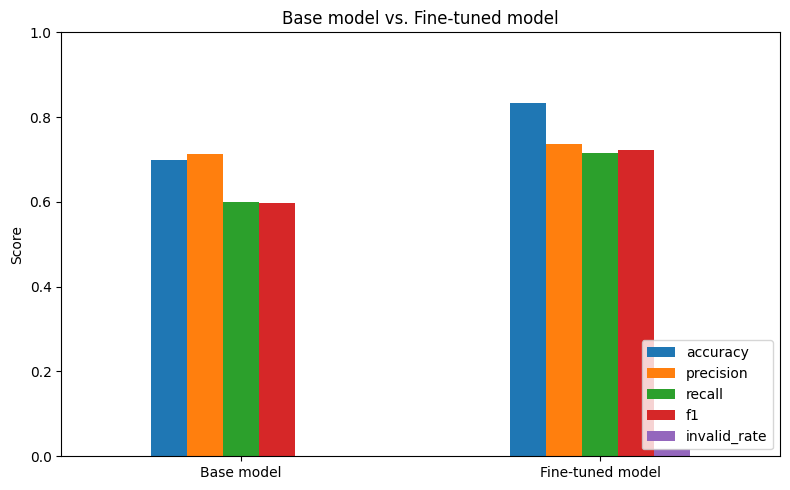

In [34]:
comparison_df.plot(kind="bar", figsize=(8, 5), rot=0)
plt.title("Base model vs. Fine-tuned model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Confusion matrices

The confusion matrix shows, for each true intent, what the model actually predicted. A well-fine-tuned model should show a strong diagonal (correct predictions).


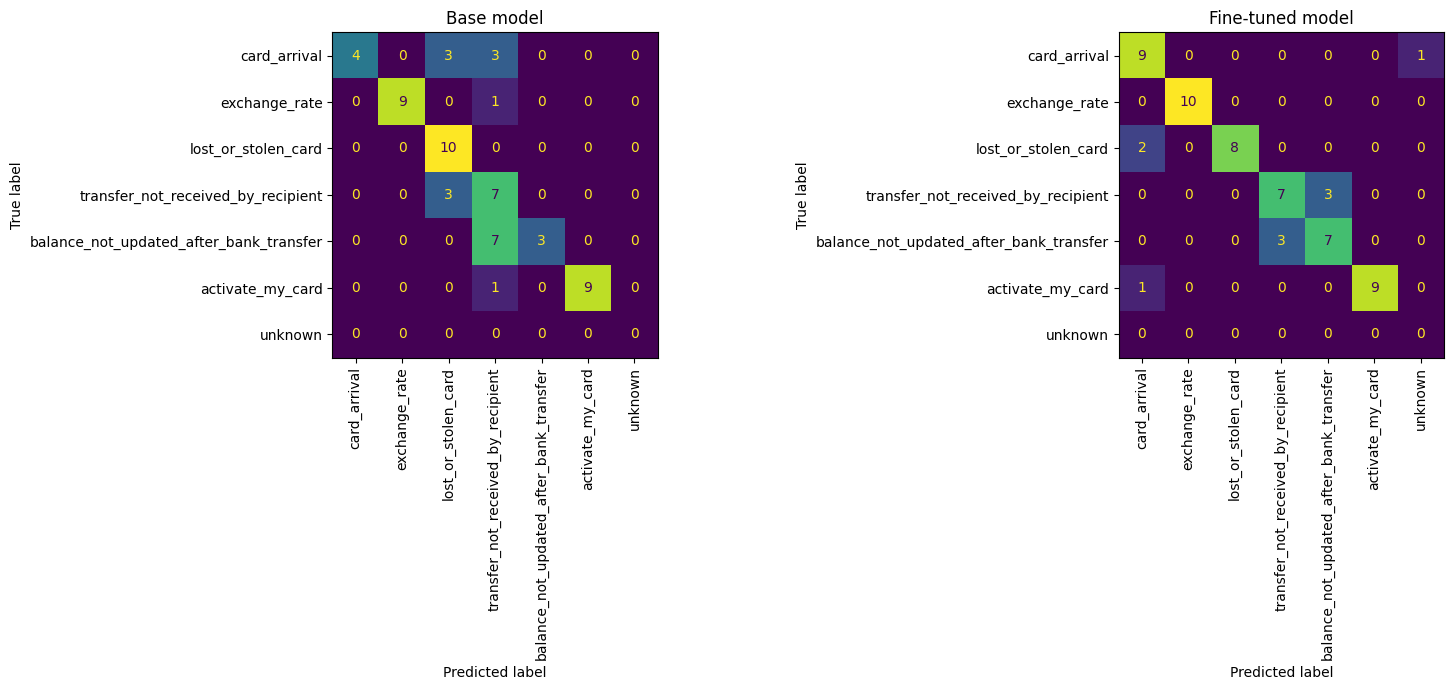

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, y_true, y_pred, title in [
    (axes[0], base_true, base_pred, "Base model"),
    (axes[1], ft_true, ft_pred, "Fine-tuned model"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
    disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()


### Side-by-side predictions

Finally, let's look at a few individual examples where the base model and the fine-tuned model disagree.


In [36]:
comparison_rows = []
for example, base_p, ft_p in zip(test_dataset, base_pred, ft_pred):
    comparison_rows.append({
        "text": example["text"],
        "ground_truth": id_to_label[example["label"]],
        "base_model": base_p,
        "fine_tuned_model": ft_p,
    })

comparison_table = pd.DataFrame(comparison_rows)
comparison_table


,text,ground_truth,base_model,fine_tuned_model
0,What is my foreign exchange rate?,exchange_rate,exchange_rate,exchange_rate
1,Im waiting for my transaction to go through.,transfer_not_received_by_recipient,transfer_not_received_by_recipient,transfer_not_received_by_recipient
2,What kind of foreign exchange rate will I get ...,exchange_rate,exchange_rate,exchange_rate
3,Help me please! My card was stolen!,lost_or_stolen_card,lost_or_stolen_card,lost_or_stolen_card
4,How long will it take to activate my new card?,activate_my_card,activate_my_card,activate_my_card
5,Why doesn't it show that I did a balance trans...,balance_not_updated_after_bank_transfer,balance_not_updated_after_bank_transfer,balance_not_updated_after_bank_transfer
6,Please advise what is the exchange rate,exchange_rate,exchange_rate,exchange_rate
7,Is there tracking info available?,card_arrival,transfer_not_received_by_recipient,unknown
8,Assist me please with card activation.,activate_my_card,activate_my_card,activate_my_card
9,I need help with activating my card,activate_my_card,activate_my_card,activate_my_card


## 10. Discussion

### What improved, and why?

- **Accuracy, precision, recall and F1 all increased** after fine-tuning, because the model learned the *exact* vocabulary and output format expected for this task — something a general-purpose base model has no way of knowing in advance.
- The fine-tuned model produces **consistently formatted** answers (just the intent label), while the base model often adds extra words or invents categories.
- We achieved this by training **less than 1% of the model's parameters** (thanks to LoRA), in just a few minutes, on a single consumer GPU.

### When should we use Fine-Tuning vs. Prompt Engineering vs. RAG?

| Technique | Best when... | Weak when... |
|---|---|---|
| **Prompt Engineering** | The task is general, instructions can be fully expressed in a prompt, and the model already "knows" the domain | Task requires a precise, specialized output format or domain vocabulary the model has never seen |
| **RAG** | The task needs up-to-date or proprietary **factual knowledge** that changes often | The task is about *behavior/format/style*, not about retrieving facts |
| **Fine-Tuning (PEFT/LoRA)** | The task needs a **consistent output format**, a specialized vocabulary or tone, and you have some labeled examples | You have very little data, or the task changes so often that retraining isn't practical |

```mermaid
flowchart TD
    Q{What does your task need?}
    Q -->|General knowledge, few instructions| PE[Prompt Engineering]
    Q -->|Fresh or private facts| RAG[RAG]
    Q -->|Specific format / vocabulary / behavior, some labeled data| FT[Fine-Tuning with PEFT]
```

### Practical guidelines

1. **Start cheap**: always try prompt engineering first — it costs nothing to iterate on.
2. **Add RAG** when the model needs facts it doesn't have (and those facts change over time).
3. **Reach for fine-tuning** when you need a *consistent, specialized* behavior that prompting can't reliably produce — as we just saw with intent classification.
4. **Use PEFT (LoRA)** instead of full fine-tuning whenever possible: it's dramatically cheaper in compute and storage, and — as we just demonstrated — it runs comfortably on a single consumer GPU.

### Next steps

In the next episode, we'll build on this fine-tuned model and integrate it into a larger **agentic pipeline**.
